# Imports

In [2]:
import pandas as pd

"""
Lightweight EDA helpers for raw exploratory analysis.
Dependencies: pandas, numpy, matplotlib, seaborn (optional), plotly, sklearn, wordcloud
"""
from collections import Counter
import logging
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
from typing import List, Optional
from wordcloud import WordCloud

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Functions

In [3]:
def summarize_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return summary: dtype, non-null count, missing pct, unique, sample values."""
    s = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "unique": df.nunique(dropna=False),
        }
    )
    s["sample_values"] = [df[col].dropna().unique()[:5].tolist() for col in df.columns]
    return s


def missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """Return top_n columns with highest missing percentage."""
    mr = (df.isna().mean() * 100).sort_values(ascending=False)
    return mr.head(top_n).to_frame("missing_pct")


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def plot_distributions(
    df: pd.DataFrame, cols: Optional[List[str]] = None, bins: int = 30, figsize=(12, 8)
):
    """Plot histograms for numeric columns (subset if cols provided)."""
    cols = cols or numeric_columns(df)
    n = len(cols)
    if n == 0:
        logger.info("No numeric columns to plot.")
        return
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, color="#4C72B0")
        ax.set_title(col)
    for ax in axes[len(cols) :]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    method: str = "spearman",
    figsize=(10, 8),
):
    """Plot correlation heatmap for numeric columns."""
    cols = cols or numeric_columns(df)
    if len(cols) < 2:
        logger.info("Need at least two numeric columns for correlation.")
        return
    corr = df[cols].corr(method=method)
    if sns:
        plt.figure(figsize=figsize)
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title(f"{method} correlation")
        plt.show()
    else:
        plt.figure(figsize=figsize)
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
        plt.title(f"{method} correlation (seaborn not installed)")
        plt.show()


def plot_pairplot_sample(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    sample_frac: float = 0.2,
    max_cols: int = 6,
):
    """Quick pairplot for a sample of numeric columns (uses seaborn if available)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    sample = df[cols].sample(frac=min(1.0, sample_frac), random_state=0)
    if sns:
        sns.pairplot(sample)
        plt.show()
    else:
        logger.info("seaborn not installed; skipping pairplot.")


def plot_pairplot_sample(
    df: pd.DataFrame,
    cols: Optional[List[str]] = None,
    sample_frac: float = 0.2,
    max_cols: int = 6,
    hue: Optional[str] = None,
):
    """Quick pairplot for a sample of numeric columns using plotly (interactive)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    if len(cols) == 0:
        logger.info("No numeric columns to plot.")
        return
    # include hue column in sample if provided and present
    sample_cols = cols[:]
    if hue and hue in df.columns and hue not in sample_cols:
        sample_cols.append(hue)
    sample = df[sample_cols].sample(frac=min(1.0, sample_frac), random_state=0)
    try:
        import plotly.express as px
    except Exception:
        logger.info("plotly not installed; skipping pairplot.")
        return
    if hue and hue in sample.columns:
        fig = px.scatter_matrix(sample, dimensions=cols, color=hue)
    else:
        fig = px.scatter_matrix(sample, dimensions=cols)
    # adjust layout for readability
    fig.update_layout(
        height=900, width=min(1200, 200 * len(cols)), title="Interactive Scatter Matrix"
    )
    fig.show()


def detect_outliers_zscore(series: pd.Series, thresh: float = 3.0) -> pd.Series:
    """Return boolean mask where True indicates an outlier by z-score."""
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - mean).abs() / std
    return z > thresh


def plot_outliers(series: pd.Series, thresh: float = 3.0):
    """Plot a series with outliers highlighted."""
    outliers = detect_outliers_zscore(series, thresh)
    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, label="Data", color="#4C72B0")
    plt.scatter(
        series.index[outliers],
        series.values[outliers],
        color="#C44E52",
        label="Outliers",
    )
    plt.title(f"Outlier Detection (z-score > {thresh})")
    plt.xlabel("Index")
    plt.ylabel(series.name)
    plt.legend()
    plt.show()


def encode_categorical_summary(
    df: pd.DataFrame, cat_cols: Optional[List[str]] = None, top_n: int = 10
) -> pd.DataFrame:
    """Return frequency tables for categorical columns (top_n values)."""
    cat_cols = (
        cat_cols or df.select_dtypes(include=["object", "category"]).columns.tolist()
    )
    out = {}
    for c in cat_cols:
        out[c] = df[c].value_counts(dropna=False).head(top_n)
    # Convert to DataFrame with MultiIndex for easy inspection
    return pd.concat(out, axis=1)


def save_profile_report(df: pd.DataFrame, path: str = "pandas_profile_report.html"):
    """Save a pandas-profiling (ydata-profiling) report if available."""
    try:
        from ydata_profiling import ProfileReport
    except Exception:
        logger.error(
            "ydata-profiling not installed. Install with: pip install ydata-profiling"
        )
        return
    profile = ProfileReport(df, minimal=True)
    profile.to_file(path)
    logger.info("Saved profile report to %s", path)


def show_class_balance(
    df: pd.DataFrame, col: str = "recommended", top_n: Optional[int] = None
) -> None:
    """
    Show class counts, proportions, and a bar chart for any boolean or categorical column.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column to analyze (default 'recommended').
    top_n : int, optional
        If set, show only the top_n most frequent categories (useful for high-cardinality columns).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    class_counts = df[col].value_counts(dropna=False)
    if top_n is not None:
        class_counts = class_counts.head(top_n)
    print(f"Class balance for '{col}':")
    print(class_counts)
    class_proportions = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .reindex(class_counts.index)
        .fillna(0)
    )
    print(f"\nClass proportions for '{col}':")
    print(class_proportions)
    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.title(f"Class balance of '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    if len(class_counts) > 6:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_votes_helpful_distribution(
    df: pd.DataFrame,
    col: str = "votes_helpful",
    bins: int = 50,
    y_log: bool = True,
    x_max_percentile: Optional[float] = 99.5,
) -> None:
    """
    Show summary stats and distribution of a vote-like column (e.g. votes_helpful).

    Prints describe() and value_counts().head(10), then a histogram. Uses log scale
    on y by default so the typical spike at 0 and the long tail are both visible.
    Optionally caps x-axis at a percentile so the bulk of the distribution is visible.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column (default 'votes_helpful').
    bins : int
        Number of histogram bins.
    y_log : bool
        If True, use log scale on y-axis.
    x_max_percentile : float, optional
        If set, limit x-axis to this percentile of the data (e.g. 99.5) to reduce
        distortion from extreme outliers.
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    series = df[col].dropna()
    print(f"Summary for '{col}':")
    print(series.describe())
    print(f"\nTop value counts:")
    print(series.value_counts().head(10))
    plt.figure(figsize=(8, 4))
    to_plot = series
    if x_max_percentile is not None:
        cap = np.nanpercentile(series, x_max_percentile)
        to_plot = series.clip(upper=cap)
    plt.hist(to_plot, bins=bins, color="#4C72B0", edgecolor="white", alpha=0.8)
    if y_log:
        plt.yscale("log")
    plt.title(
        f"Distribution of '{col}'"
        + (f" (x capped at p{x_max_percentile})" if x_max_percentile else "")
    )
    plt.xlabel(col)
    plt.ylabel("Count" + (" (log)" if y_log else ""))
    plt.tight_layout()
    plt.show()

# Load Data

In [4]:
df_sample = pd.read_csv("../../data/raw/steam_reviews_full.csv", nrows=1_000_000)

In [5]:
df_sample["language"].value_counts()

language
english       392312
russian       185744
schinese      125667
brazilian      45571
turkish        44407
spanish        42013
polish         31777
german         31066
french         26499
koreana        21153
tchinese        8131
czech           7633
italian         5737
portuguese      4249
latam           4034
hungarian       3403
thai            3148
swedish         2676
finnish         2522
danish          2352
dutch           2335
japanese        2113
ukrainian       1820
norwegian       1185
romanian        1068
greek            598
bulgarian        481
vietnamese       306
Name: count, dtype: int64

In [6]:
df_eng = df_sample[df_sample["language"] == "english"]

In [7]:
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", None)

# EDA 2: Data quality and structure


## 3. Data quality and structure

### 3.1 Missingness

Per-column % missing (or a small missingness heatmap). Focus on: `review`, `votes_helpful`, playtime, `author.*`. Use `missing_report` or similar. Decides imputation vs dropping and documents what the model actually sees.


In [8]:
# Per-column % missing; focus on review, votes_helpful, playtime, author.*
print(
    "Reviews with missing author.playtime_at_review:",
    df_eng["author.playtime_at_review"].isna().sum(),
)
missing_report(df_eng, top_n=20)

Reviews with missing author.playtime_at_review: 1198


,missing_pct
author.playtime_at_review,0.305369
review,0.196272
app_id,0.000000
app_name,0.000000
review_id,0.000000
language,0.000000
Unnamed: 0,0.000000
timestamp_created,0.000000
timestamp_updated,0.000000
votes_helpful,0.000000


## 3.2 Duplicates

In [9]:
def show_duplicates_by_columns(df, columns):
    """
    For each column in columns, print:
      - Column name
      - Number of distinct duplicated values
      - Each duplicated value and its count (>1)
    """
    for col in columns:
        # Count all values
        value_counts = df[col].value_counts(dropna=False)
        duplicated = value_counts[value_counts > 1]
        if not duplicated.empty:
            print(f"\nColumn: '{col}'")
            print(f"Number of values with duplicates: {len(duplicated)}")
            print("Duplicated values and counts:")
            print(duplicated)
        else:
            print(f"\nColumn: '{col}' has no duplicate values.")


def common_reviews(df, text_col="review", top_n=20, fig_size=None):

    counts = df[text_col].dropna().str.strip().value_counts().head(top_n)

    plt.figure(figsize=fig_size) if fig_size else plt.figure(figsize=(10, 6))

    counts.sort_values().plot(kind="barh")

    plt.xlabel("Count")
    plt.ylabel("Review Text")
    plt.title(f"Top {top_n} Most Common Full Reviews")

    plt.tight_layout()
    plt.show()

In [10]:
# Example usage:
show_duplicates_by_columns(df_eng, ["review"])


Column: 'review'
Number of values with duplicates: 9658
Duplicated values and counts:
review
yes                            3011
good                           2750
good game                      1882
10/10                          1366
.                              1129
                               ... 
so much fun\n                     2
great game with friends           2
thank you garry                   2
RDM RDM RDM RDM RDM RDM RDM       2
T T T                             2
Name: count, Length: 9658, dtype: int64


In [11]:
show_duplicates_by_columns(df_eng, ["review_id", "author.steamid"])


Column: 'review_id' has no duplicate values.

Column: 'author.steamid'
Number of values with duplicates: 20643
Duplicated values and counts:
author.steamid
76561198101732759    6
76561197979953970    6
76561198132443197    5
76561198370535442    5
76561198970966369    5
                    ..
76561198827914139    2
76561198260521634    2
76561198100334750    2
76561198332849855    2
76561198061831984    2
Name: count, Length: 20643, dtype: int64


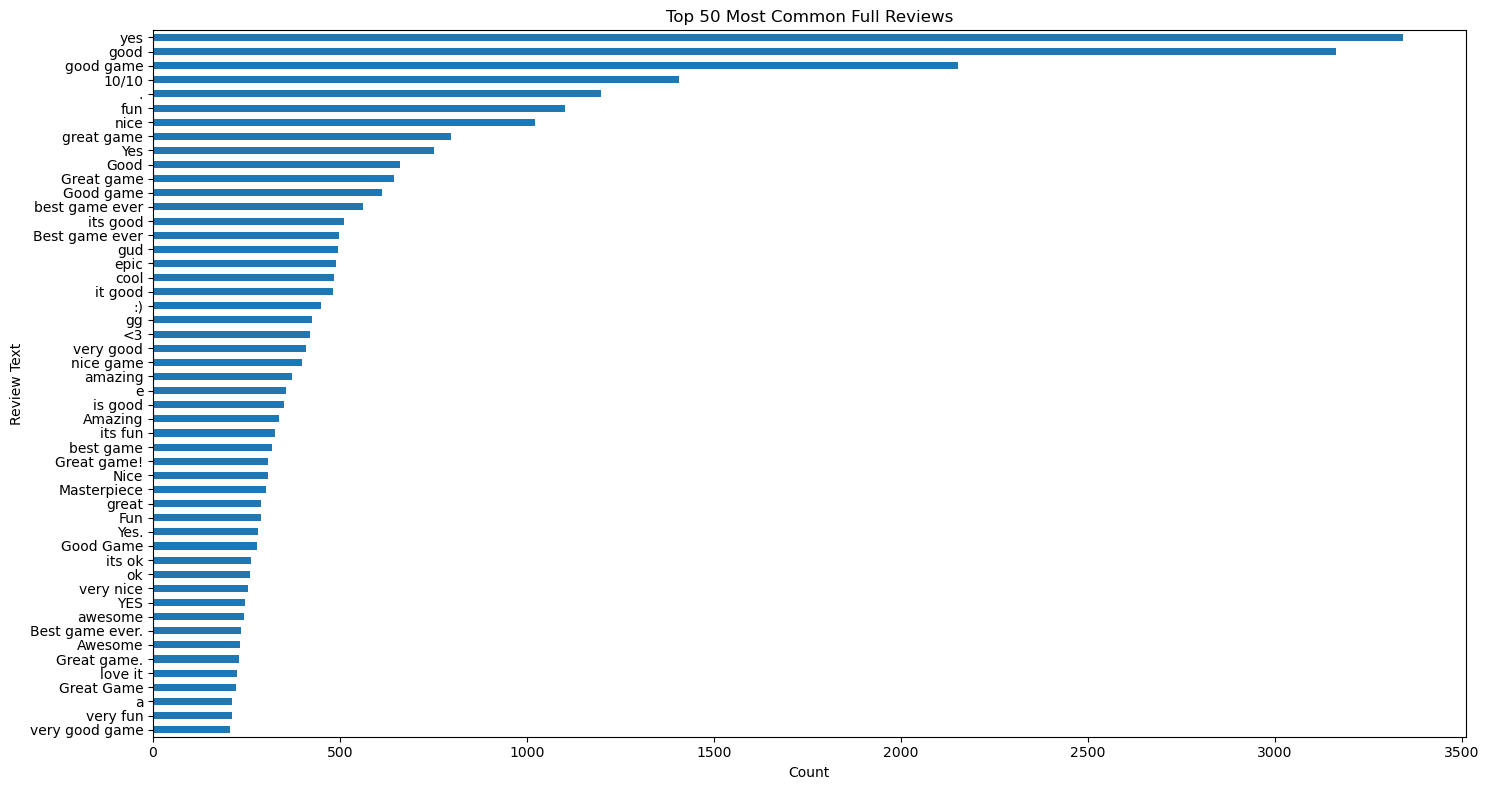

In [12]:
common_reviews(df_eng, top_n=50, fig_size=(15, 8))

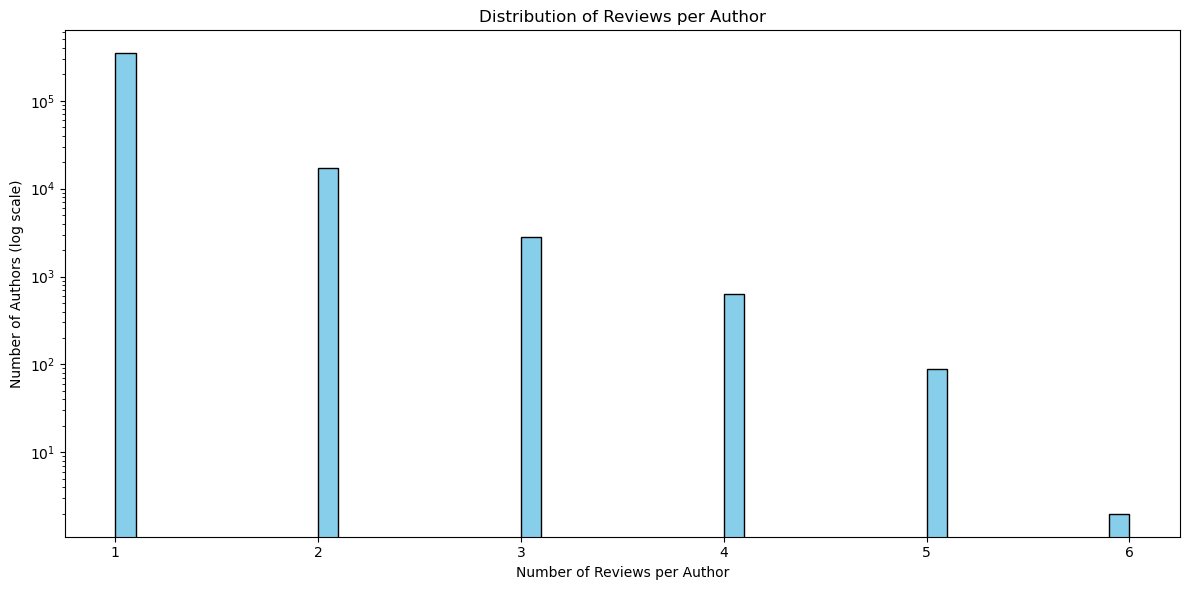

In [13]:
# Plot the distribution of number of reviews per author as a histogram

reviews_per_author = df_eng["author.steamid"].value_counts()

plt.figure(figsize=(12, 6))
plt.hist(reviews_per_author, bins=50, color="skyblue", edgecolor="black", log=True)
plt.xlabel("Number of Reviews per Author")
plt.ylabel("Number of Authors (log scale)")
plt.title("Distribution of Reviews per Author")
plt.tight_layout()
plt.show()

# This approach is standard: it counts reviews per author, then plots a histogram with log scale to reveal both rare and prolific reviewers.

In [14]:
df_eng.columns

Index(['Unnamed: 0', 'app_id', 'app_name', 'review_id', 'language', 'review',
       'timestamp_created', 'timestamp_updated', 'recommended',
       'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count',
       'steam_purchase', 'received_for_free', 'written_during_early_access',
       'author.steamid', 'author.num_games_owned', 'author.num_reviews',
       'author.playtime_forever', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'author.last_played'],
      dtype='str')

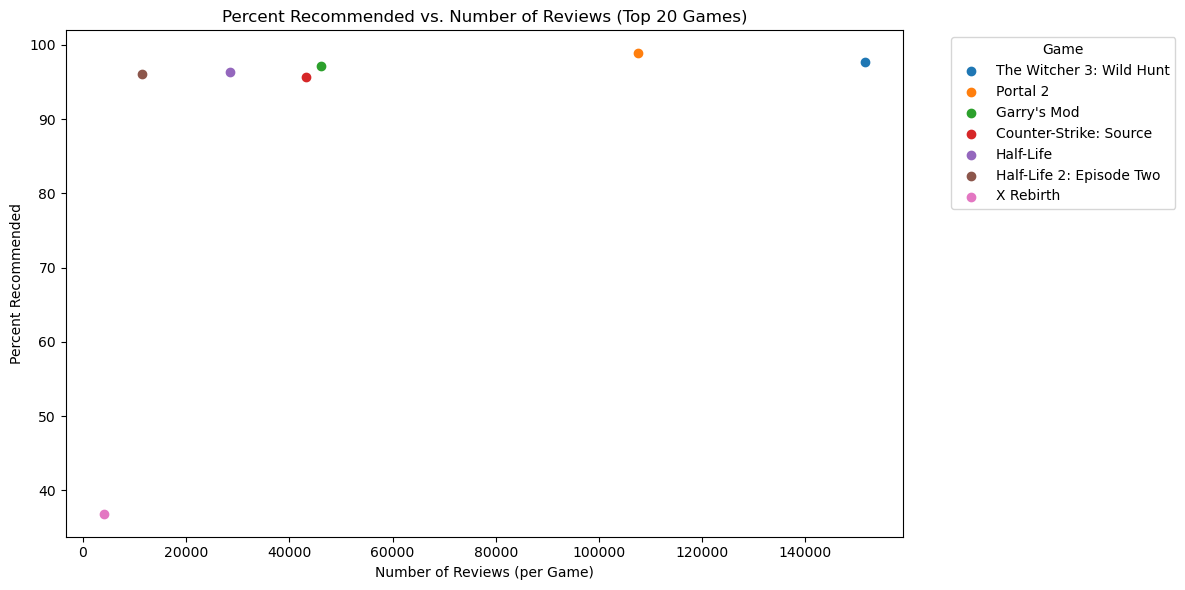

In [19]:
# Scatter plot: number of reviews per game (x) vs percentage recommended (y), colored by game with legend

# Calculate number of reviews per game
reviews_per_game = df_eng["app_name"].value_counts()

# Calculate % recommended per game
recommended_pct_per_game = (
    df_eng.groupby("app_name")["recommended"]
    .mean()
    .mul(100)  # Convert fraction to percent
)

# Align both Series (ensure same order/games)
summary = pd.DataFrame(
    {"num_reviews": reviews_per_game, "pct_recommended": recommended_pct_per_game}
).dropna()

# For visualization, pick top N games by review count to avoid excessive legend clutter
top_n = 20
top_games = summary.sort_values("num_reviews", ascending=False).head(top_n).index

plt.figure(figsize=(12, 6))

for game in top_games:
    game_data = summary.loc[[game]]
    plt.scatter(game_data["num_reviews"], game_data["pct_recommended"], label=game)

plt.xlabel("Number of Reviews (per Game)")
plt.ylabel("Percent Recommended")
plt.title(f"Percent Recommended vs. Number of Reviews (Top {top_n} Games)")
plt.legend(title="Game", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# This plot shows, for each of the top games, how review count relates to the percent of "recommended" reviews.
# Each point represents a game; color and legend distinguish games; percent recommended is the mean of the binary 'recommended' field per game.